In [ ]:
# %pip install -U langgraph langsmith langchain_anthropic --ignore-installed


  Using cached langchain_anthropic-0.3.10-py3-none-any.whl.metadata (1.9 kB)
  Using cached httpx-0.28.1-py3-none-any.whl.metadata (7.1 kB)
  Using cached packaging-24.2-py3-none-any.whl.metadata (3.2 kB)
  Using cached pydantic-2.10.6-py3-none-any.whl.metadata (30 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached requests_toolbelt-1.0.0-py2.py3-none-any.whl.metadata (14 kB)
  Using cached zstandard-0.23.0-cp313-cp313-win_amd64.whl.metadata (3.0 kB)
  Using cached anthropic-0.49.0-py3-none-any.whl.metadata (24 kB)
  Using cached anyio-4.9.0-py3-none-any.whl.metadata (4.7 kB)
  Using cached distro-1.9.0-py3-none-any.whl.metadata (6.8 kB)
  Using cached jiter-0.9.0-cp313-cp313-win_amd64.whl.metadata (5.3 kB)
  Using cached sniffio-1.3.1-py3-none-any.whl.metadata (3.9 kB)
  Using cached certifi-2025.1.31-py3-none-any.whl.metadata (2.5 kB)
  Using cached httpcore-1.0.7-py3-none-any.whl.metadata (21 kB)
  Using cached idna-3.10-py3-none-any.whl.metadata (1


[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import os

ANTHROPIC_API_KEY = "ANTHROPIC_API_KEY"

os.environ["ANTHROPIC_API_KEY"] = ANTHROPIC_API_KEY

TAVILY_API_KEY = "TAVILY_API_KEY"

os.environ["TAVILY_API_KEY"] = TAVILY_API_KEY

In [3]:
from typing import Dict, TypedDict, Annotated
from typing_extensions import TypedDict
from langgraph.graph.message import add_messages

class LangGraphAgentState(TypedDict):
    name: str
    personality: str
    style: str
    stake_amount: int
    current_message: str
    messages: list
    decisions: list

In [5]:
import asyncio, websockets, aiohttp, json, random
from langchain_community.tools.tavily_search import TavilySearchResults
from langchain_anthropic import ChatAnthropic
from langgraph.graph import StateGraph
from langgraph.types import Command, interrupt
from langgraph.prebuilt import ToolNode, tools_condition

from dotenv import load_dotenv

import os
import asyncio
from langchain_core.tools import tool

In [9]:
@tool
def human_assistance(query: str) -> str:
    """Request assistance from a human."""
    human_response = interrupt({"query": query})
    return human_response["data"]

ValidationError: 1 validation error for TavilyInput
  Input should be a valid dictionary or instance of TavilyInput [type=model_type, input_value=<function human_assistance at 0x0000016A6C9698A0>, input_type=function]
    For further information visit https://errors.pydantic.dev/2.10/v/model_type

In [ ]:
def make_decision(state: LangGraphAgentState) -> LangGraphAgentState:
    ai_message = llm_with_tools.invoke(state.messages)
    
    state.decisions.append(ai_message.content)

    return state

tool = TavilySearchResults(max_results=2)
tools = [tool, human_assistance]
llm = ChatAnthropic(model="claude-3-5-sonnet-20240620")
llm_with_tools = llm.bind_tools(tools)

tool_node = ToolNode(tools=tools)

def create_graph() -> StateGraph:
    workflow = StateGraph(LangGraphAgentState)

    workflow.add_node("make_decision", make_decision)
    workflow.add_node("tools", tool_node)

    workflow.set_entry_point("make_decision")
    workflow.set_entry_point("tools")

    workflow.add_conditional_edges(
        "make_decision",
        tools_condition
    )

    workflow.add_edge("tools", "make_decision")

    return workflow.compile()

graph = create_graph()

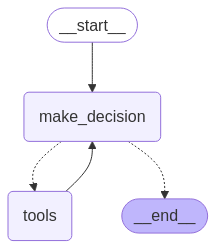

In [24]:
from IPython.display import Image, display

try:
    display(Image(graph.get_graph().draw_mermaid_png()))
except:
    pass